# **Collecting Job Data Using APIs**


## Objectives


*   Collect job data using Jobs API
*   Store the collected data into an excel spreadsheet.


### Objective: Determine the number of jobs currently open for various technologies  and for various locations


Collect the number of job postings for the following locations using the API:

* Los Angeles
* New York
* San Francisco
* Washington DC
* Seattle
* Austin
* Detroit


In [1]:
#Import required libraries
import pandas as pd
import json
import requests # you need this module to make an API call
import pandas as pd


In [2]:
api_url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/module%201/Accessing%20Data%20Using%20APIs/jobs.json"

def get_number_of_jobs_T(technology):
    response = requests.get(api_url)
    if response.ok:
        data = response.json()
        count = 0
        for job in data:
            if technology.lower() in job.get("Key Skills", "").lower():
                count += 1

    return technology,count


Calling the function for Python and checking if it works.


In [3]:
get_number_of_jobs_T("Python")

('Python', 1173)

#### Write a function to find number of jobs in US for a location of your choice


In [4]:
def get_number_of_jobs_L(location):
    count1 =0
    response = requests.get(api_url)
    if response.ok:
        data = response.json()
    for job in data:
        if location in job.get("Location", ""):
            count1+=1
    return location,count1

Call the function for Los Angeles and check if it is working.


In [5]:
get_number_of_jobs_L("Los Angeles")

('Los Angeles', 640)

### Store the results in an excel file


Call the API for all the given technologies above and write the results in an excel spreadsheet.


Create a python list of all technologies for which you need to find the number of jobs postings.


In [6]:
tech = ["C","C#","C++","Java","JavaScript","Python","Scala","Oracle","SQL Server","MySQL Server","PostgreSQL","MongoDB"]

Import libraries required to create excel spreadsheet


In [7]:
!pip install openpyxl
from openpyxl import Workbook

Create a workbook and select the active worksheet


In [8]:
wb = Workbook()
ws1 = wb.active

Find the number of jobs postings for each of the technology in the above list.
Write the technology name and the number of jobs postings into the excel spreadsheet.


In [9]:
ws1.append(['Technology','no. of job postings'])

In [11]:
response = requests.get(api_url)

if response.ok:
    data = response.json()

    for technology in tech:
        count = 0

        # Loop through all job postings
        for job in data:
            key_skills = job.get("Key Skills", "")

            if technology.lower() in key_skills.lower():
                count += 1

        # Write result to Excel
        ws1.append([technology, count])

Save into an excel spreadsheet named **job-postings.xlsx**.


In [12]:
wb.save("job-postings.xlsx")

Visualizing Job posting by technology.

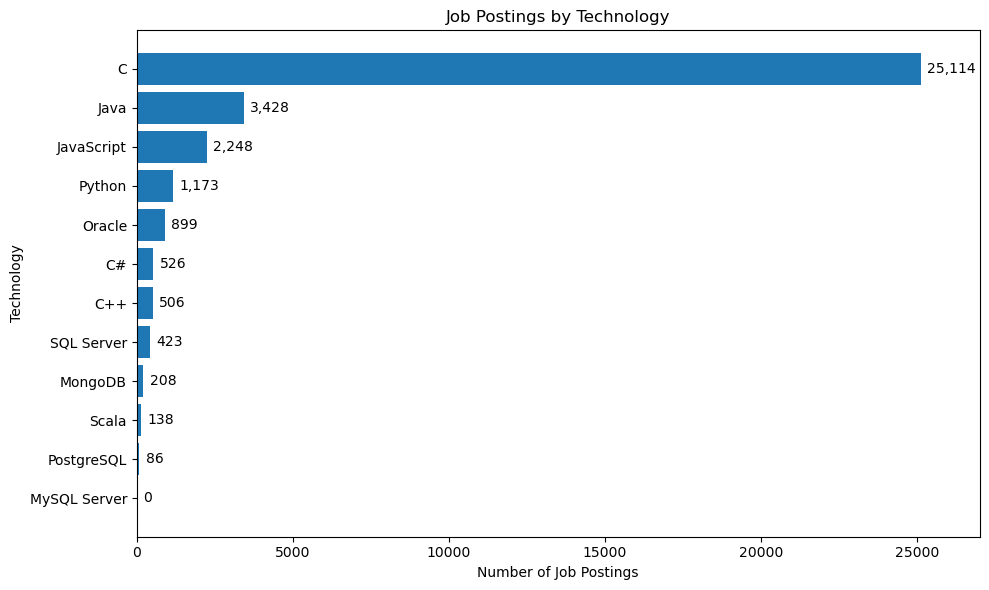

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("job-postings.xlsx")

df = df.sort_values(
    by="no. of job postings",
    ascending=False
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    df["Technology"],
    df["no. of job postings"]
)

plt.gca().invert_yaxis()

# Add values to bars
for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 200,
        bar.get_y() + bar.get_height()/2,
        f"{int(value):,}",
        va="center"
    )
plt.xlim(0, 27000)
plt.xlabel("Number of Job Postings")
plt.ylabel("Technology")
plt.title("Job Postings by Technology")

plt.tight_layout()
plt.show()
